# Jornada de IA
## Introdução a Algoritmos de Machine Learning & IA generativa

**Time:** Motiva
**Instrutor:** Rafael Monteiro (rafael.a.monteiro.math@gmail.com)

___

# 1. Lab #1

## 1.1 Regressão Linear

Para começarmos, vamos importar algumas bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_PATH = "images"
plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

In [2]:
np.random.seed(42)
m = 80  # number of instances
X = 2 * np.random.rand(m, 1)  # column vector
y = (
    4 + 4 * X + 6 * np.pow(X, 2) - 3 * np.pow(X, 3) + 0.1 * np.random.randn(m, 1)
)  # column vector

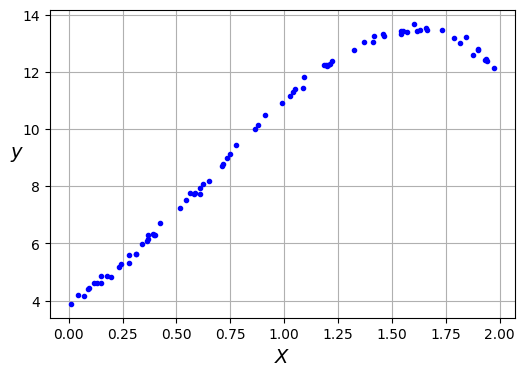

In [3]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$X$")
plt.ylabel("$y$", rotation=0)
plt.grid()
plt.show()

Voce gostaria de entender a relacao entre as variaveis X e Y. Por exemplo:

1. O que aconteceria se quisessemos saber o valor dessa função em X = 1.23? (Generalização/Interpolação)
2. E se quisessemos saber o valor dessa função em X = 3? (Extrapolação)

Uma das hipoteses principais do modelo de regressao e que a relacao entre as variaveis Y (resposta) e X e que

$$ Y = f(X) + \varepsilon, \tag{1}$$

onde  $f$ e uma função que teremos que procurar. Em geral ela faz parte de uma familia de funcoes de um determinado tipo. Por exemplo, poderiamos procurar por funcoes do tipo

$$Y = a + bX  + \text{erro}, \tag{2}$$

onde os parametros a e b sao desconhecidos. Neste caso, o problema e o que chamamos de regressao linear.

Note que podemos aumentar a complexidade do modelo, buscando por familias ainda mais complexas, como 


$$ Y = a + bX + c X^2 + \varepsilon,$$

ou mesmo funcões de graus maiores.


Vamos ver o que acontece quando aproximamos nosso modelo por funcoes de determinado grau. 


In [4]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=4, include_bias=True)
X_poly = poly_features.fit_transform(X)

In [5]:
X_poly.shape, X.shape

((80, 5), (80, 1))

In [6]:
X_poly[:2]

array([[ 1.        ,  0.74908024,  0.5611212 ,  0.4203248 ,  0.314857  ],
       [ 1.        ,  1.90142861,  3.61543077,  6.87448351, 13.07133965]])

A biblioteca que utilizaremos para fazer regressão linear será a seguinte

In [7]:
from sklearn.linear_model import LinearRegression

Por agora, otimizaremos diversos modelos em um gráfico só, mas veremos que fica melhor plotarmos cada grau em separado.

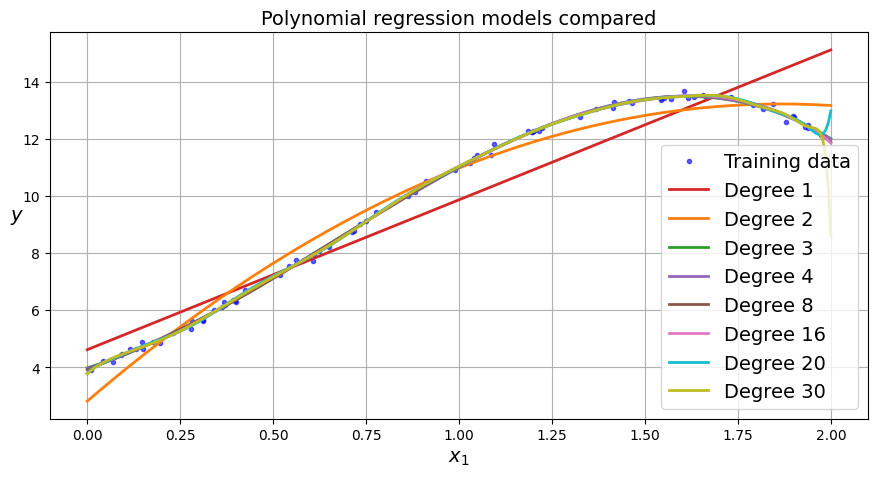

In [ ]:
# Fit models of increasing polynomial degre
degrees = [1, 2, 3, 4, 8, 16, 20, 30]
colors = [
    "tab:red",
    "tab:orange",
    "tab:green",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:cyan",
    "tab:olive",
]

X_plot = np.linspace(0, 2, 300).reshape(-1, 1)

plt.figure(figsize=(9, 5))
plt.plot(X, y, "b.", alpha=0.6, label="Training data")

for degree, color in zip(degrees, colors):
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly_train = poly.fit_transform(X)
    X_poly_plot = poly.transform(X_plot)

    model = LinearRegression()
    model.fit(X_poly_train, y)
    y_plot = model.predict(X_poly_plot)

    plt.plot(X_plot, y_plot, color=color, linewidth=2, label=f"Degree {degree}")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.xlim(-0.1, 2.1)
plt.legend()
plt.grid()
plt.title("Polynomial regression models compared")
plt.tight_layout()
plt.show()

Cmo dito anteriormente, é melhor visualizarmos o comportamento de cada curva em separado. 

Vamos gerar uma animação para isso. 

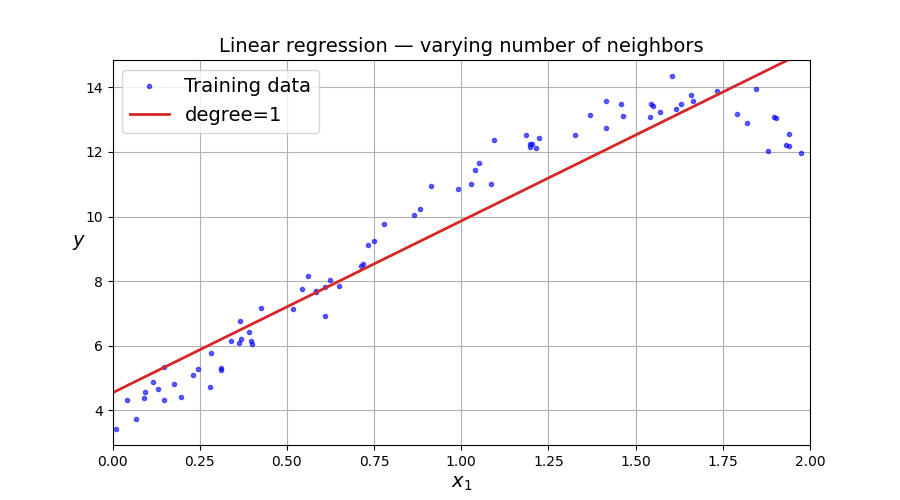

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image

# Re-generate data (same seed as above)
degrees = np.array([1, 2, 3, 4, 8, 16, 20, 30], dtype=int)
colors = [
    "tab:red",
    "tab:orange",
    "tab:green",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:cyan",
    "tab:olive",
]
np.random.seed(42)
m = 80
X_reg = 2 * np.random.rand(m, 1)
y_reg = (
    4 + 4 * X + 6 * np.pow(X, 2) - 3 * np.pow(X, 3) + 0.4 * np.random.randn(m, 1)
)  # column vector

X_plot = np.linspace(0, 2, 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(9, 5))


def make_frame(k):
    ax.clear()
    ax.plot(X_reg, y_reg, "b.", alpha=0.6, label="Training data")
    degree_now = degrees[k - 1]
    poly = PolynomialFeatures(degree=degree_now, include_bias=True)
    X_poly_train = poly.fit_transform(X_reg)
    X_poly_plot = poly.transform(X_plot)

    model = LinearRegression()
    model.fit(X_poly_train, y_reg)
    y_plot = model.predict(X_poly_plot)

    ax.plot(X_plot, y_plot, color="tab:red", linewidth=2, label=f"degree={degree_now}")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$y$", rotation=0)
    ax.set_xlim(0, 2)
    ax.set_ylim(y_reg.min() - 0.5, y_reg.max() + 0.5)
    ax.legend(loc="upper left")
    ax.grid()
    ax.set_title("Linear regression — varying number of neighbors")


frames = list(range(1, 9))
ani = animation.FuncAnimation(fig, make_frame, frames=frames, interval=800)

gif_path = "images/linear_regression.gif"
ani.save(gif_path, writer="pillow", fps=1)
plt.close()

Image(gif_path)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_blobs, make_circles
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

# Use the original data from the beginning of the session
np.random.seed(42)
m = 80
X_cv = 2 * np.random.rand(m, 1)
y_cv = (
    4
    + 4 * X_cv
    + 6 * np.pow(X_cv, 2)
    - 3 * np.pow(X_cv, 3)
    + 0.1 * np.random.randn(m, 1)
).ravel()

# ── Build candidate models ───────────────────────────────────────────────────
poly_degrees = [1, 2, 3, 4, 8, 16, 20, 30]

candidates = {
    deg: make_pipeline(
        PolynomialFeatures(degree=deg, include_bias=True), LinearRegression()
    )
    for deg in poly_degrees
}

# ── Cross-validate (5-fold, scored by RMSE) ──────────────────────────────────
results = []
for deg, model in candidates.items():
    scores = cross_val_score(
        model, X_cv, y_cv, cv=5, scoring="neg_root_mean_squared_error"
    )
    rmse_mean = -scores.mean()
    rmse_std = scores.std()
    results.append(
        {
            "degree": deg,
            "model": f"PolyReg degree={deg}",
            "RMSE (mean)": rmse_mean,
            "RMSE (std)": rmse_std,
        }
    )

results_df = pd.DataFrame(results).sort_values("RMSE (mean)").reset_index(drop=True)
print(results_df.to_string(index=False))

best = results_df.iloc[0]
print(
    f"\n✓ Best model: {best['model']}  —  CV RMSE = {best['RMSE (mean)']:.4f} ± {best['RMSE (std)']:.4f}"
)

 degree             model  RMSE (mean)  RMSE (std)
      3  PolyReg degree=3     0.096088    0.015208
      4  PolyReg degree=4     0.097978    0.016384
      8  PolyReg degree=8     0.101292    0.017640
     16 PolyReg degree=16     0.159675    0.127516
     20 PolyReg degree=20     0.166928    0.138143
     30 PolyReg degree=30     0.311717    0.420531
      2  PolyReg degree=2     0.478452    0.041545
      1  PolyReg degree=1     1.037720    0.049262

✓ Best model: PolyReg degree=3  —  CV RMSE = 0.0961 ± 0.0152


In [11]:
results_df.sort_values(by="degree", ascending=True, inplace=True)

In [12]:
x_, y_ = results_df["degree"].tolist(), results_df["RMSE (mean)"].tolist()

Quando plotamos o erro quadrático médio versus o grau do polinômio, vemos que algo curioso acontece:
1. Inicialmente, o erro parece diminuir com o aumento do grau do polinômio.
2. No entanto, após grau 3, o modelo parece piorar, indicnao que há uma deterioração na capacidade do modelo generalizar.

Este é um exemplo claro do `trade-off viés-variância`. 

* O modelo, quando pouco complexo (grau baixo), é incapaz de aproximar a distribuição "correta" que relaciona X a Y. Há assim um grande viés, embora pouca sensibilidade quanto aos dados utilizados na amostra (baixa variância).
* Por outro lado, quando o modelo fica complexo demais (alto grau de polinômio) ele passa a ficar muito sensível ao ruído intrínseco à amostra de dados. Isso faz com que ele deteriore em qualidade de generalização. O viés, no entanto, é baixo. 

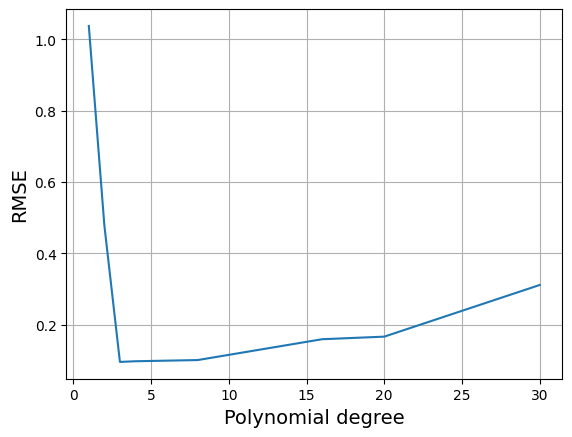

In [13]:
plt.plot(x_, y_)
plt.ylabel("RMSE")
plt.xlabel("Polynomial degree")
plt.grid()
plt.show()

## 1.2 Outras formas de se fazer regressão

Existem outras formas de se fazer regressão ditas "não paramétricas" (ou seja, sem parâmetros, como a e b na equação (2)).

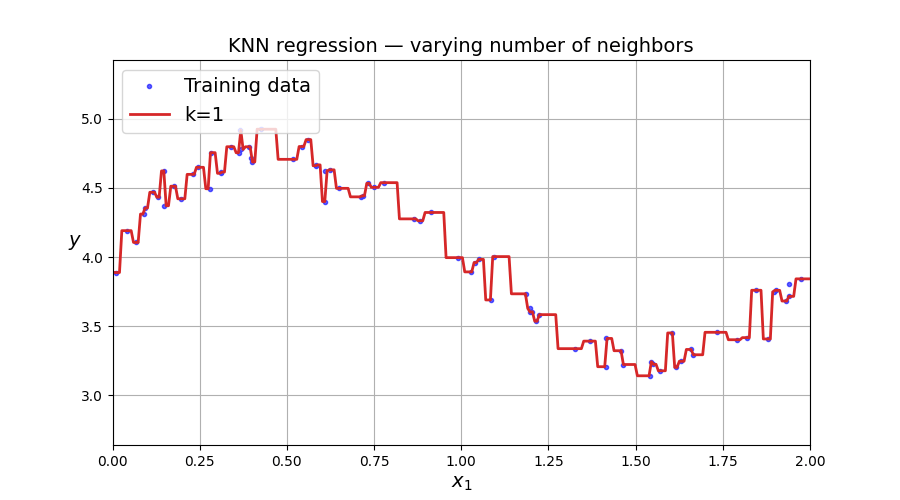

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image

# Re-generate data (same seed as above)
np.random.seed(42)
m = 80
X_reg = 2 * np.random.rand(m, 1)
y_reg = (
    4
    + 4 * X_reg
    - 6 * np.pow(X_reg, 2)
    + 2 * np.pow(X_reg, 3)
    + 0.1 * np.random.randn(m, 1)
)

X_plot = np.linspace(0, 2, 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(9, 5))


def make_frame(k):
    ax.clear()
    ax.plot(X_reg, y_reg, "b.", alpha=0.6, label="Training data")

    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_reg, y_reg.ravel())
    y_plot = model.predict(X_plot)

    ax.plot(X_plot, y_plot, color="tab:red", linewidth=2, label=f"k={k}")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$y$", rotation=0)
    ax.set_xlim(0, 2)
    ax.set_ylim(y_reg.min() - 0.5, y_reg.max() + 0.5)
    ax.legend(loc="upper left")
    ax.grid()
    ax.set_title("KNN regression — varying number of neighbors")


frames = list(range(1, 9))
ani = animation.FuncAnimation(fig, make_frame, frames=frames, interval=800)

gif_path = "images/knn_regression.gif"
ani.save(gif_path, writer="pillow", fps=1)
plt.close()

Image(gif_path)

### 1.2.1 Perguntas

A. Em um caso de extrapolacão, como o modelo se comporta?
B. O que acontece com o modelo quando k toma valores muito altos (como, por exemplo, acima do número de pontos amostrados)?



# 1.3 Modelos de Classificacao - Árvores de decisão

![Alt text](images/iris_different_kinds_white.png)

Uma ótima referência para esta parte - a qual seguiremos de perto, é o livro do [Aurelien Geron, capítulo 6](https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/).

Faremos o seguinte: importaremos um conjunto de dados clássico com dados sobre flores do tipo iris. As classificaremos utilizando informações sobre

* Comprimento das pétalas
* Largura das pétalas

In [15]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

Utilizaremos mum modelo de classificação do tipo `árvore de decisão`. Este modelo tem uma ótima qualidade de ser facilmente interpretável. 

In [16]:
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Para entendermos melhor o que está acontecendo plotaremos a árvore de decisão que rege o modelo. 

In [17]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file=IMAGES_PATH + "/iris_tree.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True,
)

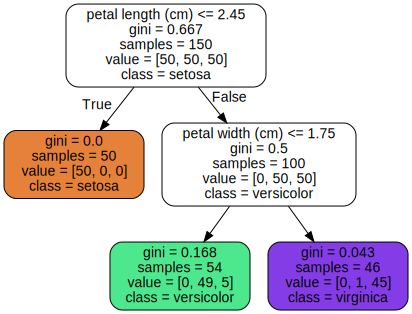

In [18]:
from graphviz import Source

Source.from_file(IMAGES_PATH + "/iris_tree.dot")

Podemos olhar no espaço de parêmatros para melhor entender como as decisões são tomadas, além de como a amostra se situa em relação às fronteiras de decisão.

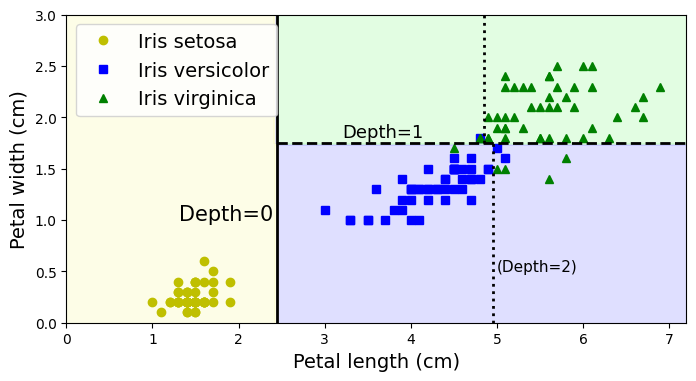

In [19]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (deg, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(
        X_iris[:, 0][y_iris == idx],
        X_iris[:, 1][y_iris == idx],
        style,
        label=f"Iris {deg}",
    )

# extra code – this section beautifies and saves Figure 6–2
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

No caso de um aárvore de decisão, podemos pedir para o modelo nos retornar a probabilidade de pertecimento a cada classe. 

In [20]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [21]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 1.3.1 Exercício - Dependência de coordenadas


Considere o seguinte exemplo:

In [22]:
X = np.random.normal(size=(100, 2), scale=3)

Y = (X[:, 0] > 0) * 1

Este conjunto é "totalmente separável": existe uma reta que  separa os indivíduos das duas classes (a reta `X =0`). 

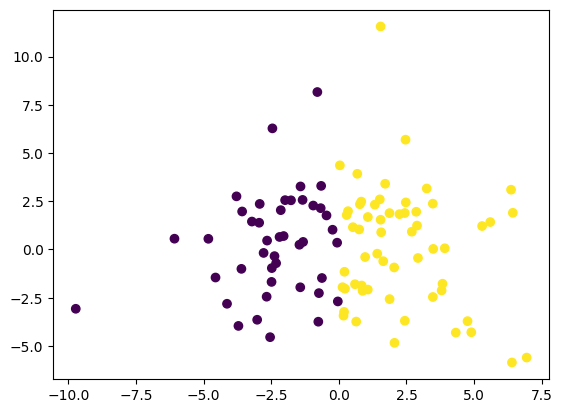

In [23]:
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()

Vamos classificar o modelo utilizando uma árvpre de decisão. 

In [24]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
dec_tree = DecisionTreeClassifier(max_depth=3)

dec_tree.fit(X, Y)

y_pred = dec_tree.predict(X)

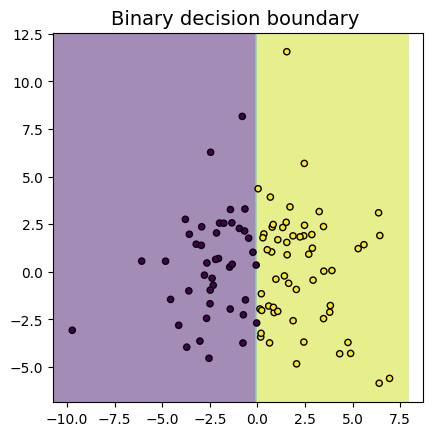

In [26]:
disp = DecisionBoundaryDisplay.from_estimator(
    dec_tree,
    X,
    response_method="predict",
    alpha=0.5,
)
disp.ax_.scatter(X[:, 0], X[:, 1], c=Y, s=20, edgecolor="k")
disp.ax_.set_title("Binary decision boundary ")
plt.axis("square")
plt.show()

Agora vou pedir para vocês rotacionarem os dados em 60 graus no sentido horário. 

In [27]:
theta = np.pi / 3
orthogonal = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])

In [28]:
X_mapped = (orthogonal @ X.T).T

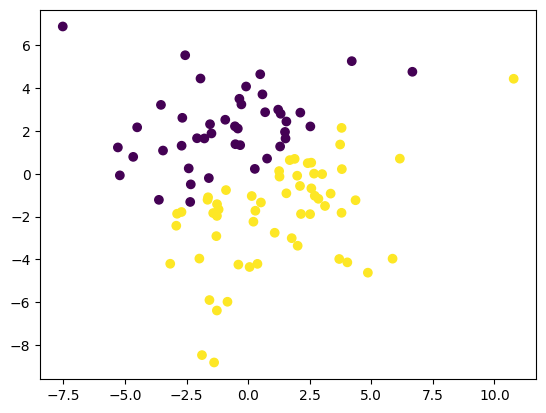

In [29]:
plt.scatter(X_mapped[:, 0], X_mapped[:, 1], c=Y)
plt.show()

1. Otimize um modelo de classificação do tipo árvore de decisão para o problema acima. Note que somente o valor de X mudou, não o valor de Y.

```
dec_tree = DecisionTreeClassifier(max_depth=3)

dec_tree.fit(X_mapped,Y)

y_pred = dec_tree.predict(X_mapped)
```

In [30]:
dec_tree = DecisionTreeClassifier(max_depth=3)

dec_tree.fit(X_mapped, Y)

y_pred = dec_tree.predict(X_mapped)

2. Plote a fronteira de decisão do modelo e observe o que acontece com a mesma. Observe que o modelo é incapáz de reproduzir a fronteira reta (ideal) como antes. 
3. Tente ajustar o parâmetro `max_depth` para ver como a fronteira se comporta - mais regular à medida que àmax_depth` aumenta ou menos regular?

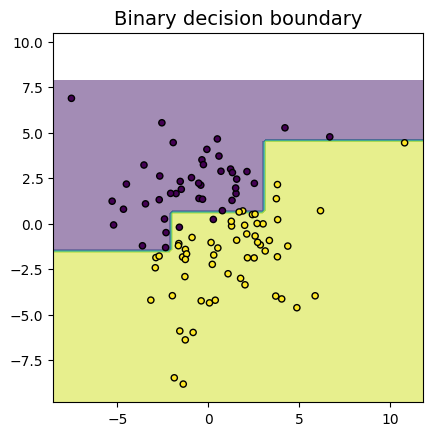

In [31]:
disp = DecisionBoundaryDisplay.from_estimator(
    dec_tree,
    X_mapped,
    response_method="predict",
    alpha=0.5,
)
disp.ax_.scatter(X_mapped[:, 0], X_mapped[:, 1], c=Y, s=20, edgecolor="k")
disp.ax_.set_title("Binary decision boundary")
plt.axis("square")
plt.show()

## 1.3.2 Exercícios -  Outras ideias relacionadas a separacao por hiperplanos

Muitas vezes e obvio que dois conjuntos de pontos nao sao separaveis por uma reta. Por exemplo:

In [32]:
X = np.arange(-10, 11, 1)
Y_nonlinear = 1 * (np.abs(X) >= 5)

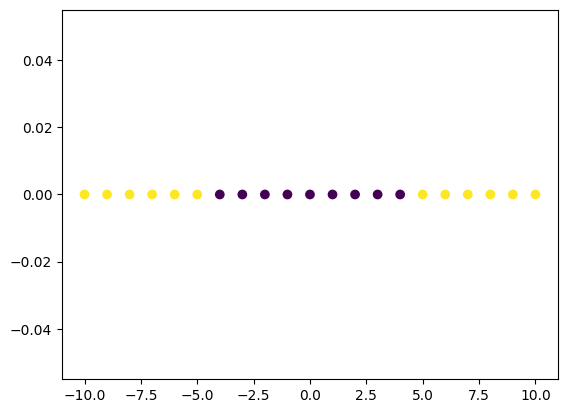

In [33]:
plt.scatter(X, np.zeros_like(X), c=Y_nonlinear)
plt.show()

No entanto, se estendermos o conjunto X como um par to tipo 

$$(x, x^2)$$

este conjunto passa a ser separável:


In [34]:
X.shape

(21,)

In [35]:
X_extended = np.c_[(np.array(X).reshape(-1, 1), np.array(X.reshape(-1, 1)) ** 2)]

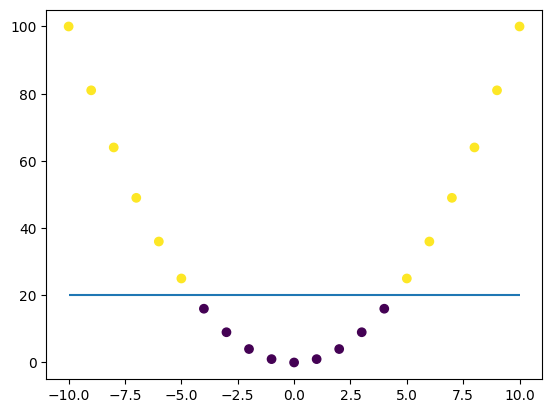

In [36]:
plt.scatter(X_extended[:, 0], X_extended[:, 1], c=Y_nonlinear)
plt.hlines(y=20, xmin=-10, xmax=10)
plt.show()

De certa maneira, esta é uma ideia explorada por alguns métodos, como as máquinas de suporte vetorial (_support vector machines_).

## 1.4 Ensembles

Poderia ser o caso que treinamos diferentes modelos e fazemos uma votação dentre eles quanto à classe a qual um individuo pertence

In [37]:
dec_tree_1 = DecisionTreeClassifier(splitter="random", max_depth=4)
dec_tree_2 = DecisionTreeClassifier(splitter="random", max_depth=4)
dec_tree_3 = DecisionTreeClassifier(splitter="random", max_depth=4)

Uma vez que tenhamos otimizado estes 3 modelos, vamos agregar os resultados dos mesmos da seguinte forma:
* cada previsão que faremso passará pelos 3 modelos
* ao final, a decisão dos 3 modelos serão consideradas como votos. 

In [38]:
from sklearn.ensemble import VotingClassifier

In [39]:
voting = VotingClassifier(
    estimators=[
        ("dec_1", dec_tree_1),
        ("dec_2", dec_tree_2),
        ("dec_3", dec_tree_3),
    ],
    voting="hard",
)

In [40]:
voting.fit(X_mapped, Y)

,estimators,"[('dec_1', ...), ('dec_2', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,criterion,'gini'
,splitter,'random'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1


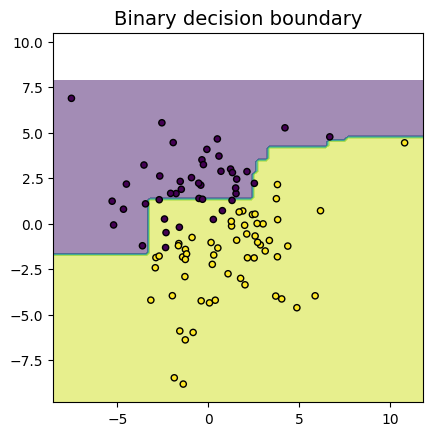

In [41]:
# scatter = plt.scatter(X_mapped[:, 0], X_mapped[:, 1], c=y_pred, s=20, edgecolor="k")

disp = DecisionBoundaryDisplay.from_estimator(
    voting,
    X_mapped,
    response_method="predict",
    alpha=0.5,
)
disp.ax_.scatter(X_mapped[:, 0], X_mapped[:, 1], c=Y, s=20, edgecolor="k")
disp.ax_.set_title("Binary decision boundary")
plt.axis("square")
plt.show()

Essa ideia de pegarmos diversas arvores de decisão e as utilizarmos para classificação é o que chamamos de técnica de "ensemble"  (conjunto, em Francês).

O que fizemos acima é, de certa maneira, uma mini Árvore aleatória. Frisamos que há metodos mais eficientes de construí-las.



### 1.4.1 Exercicio. - Árvores aleatórias

NEste exercício ainda utilizaremos os dados `(X_mapped, Y)` Vocês irao construir uma árvore aleatória da seguinte forma

1. importe a biblioteca 

```
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
```

2. Escolhido um modelo específico (por ex, uma arvore de decisáo) o  método de Bagging funciona da seguinte forma: 
* amostra-se do conjunto de treinamento com repeticão, e se treina naquele conjunto. 
* Isso é repetido or um número N de vezes. 
* O treinamento então acontece para diversos modelos, com conjuntos de dados que sáo subpopulacões da amostra original de treinamento. (Isso é definido no parâmetro bootstrap = True; quando definido como False a amostragem deixa de ser com repeticao e o metodo se chama "Pasting")

3. Defina um classificador do tipo Bagging fazendo

```
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    max_samples=100, bootstrap=True, n_jobs=-1)
```
O que significa o parametro max_samples? e o Parametro n_jobs?
4. 
Otimize o modelo 
```
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
```


5. Como fica a fronteira de decisão neste caso?